In [ ]:
# ============================================================
# CELL 1: Data Loading & Inspection
# ============================================================
# PURPOSE: Import libraries, mount Google Drive, load the raw
# Excel file, and inspect its structure.
# RULE: We do NOT modify or clean anything in this cell.
#       We only load and look. This keeps our pipeline auditable.
# ============================================================


# --- SECTION 1A: Import Libraries ---
# Think of imports like pulling equipment off the shelf.
# We do this once, at the top, so every cell below has access.

import pandas as pd
# Pandas is our core data tool. It reads files and stores data
# in a structure called a DataFrame — imagine a spreadsheet
# that lives in Python and that you can filter, reshape,
# and calculate on programmatically.

import numpy as np
# NumPy (Numerical Python) works underneath Pandas and gives us
# fast math operations on arrays of numbers.
# We'll use it later for things like calculating means and
# standard deviations across replicates.

import matplotlib.pyplot as plt
# Matplotlib is our graphing engine. We import the "pyplot"
# submodule, which gives us a MATLAB-style interface for
# building figures step by step.
# We alias it as "plt" — this is a universal convention.

import seaborn as sns
# Seaborn is built ON TOP of matplotlib and makes
# publication-quality statistical plots much easier to build.
# It will be our primary graphing tool in later cells.

print("✓ Libraries imported successfully")


# --- SECTION 1B: Mount Google Drive ---
# Google Colab runs on a virtual machine (a temporary computer
# in the cloud). It cannot see your files by default.
# "Mounting" Drive is like plugging in a USB drive —
# it makes your Google Drive folder visible to this machine.

from google.colab import drive
drive.mount('/content/drive')

# After running this cell, a popup will ask you to authorize
# access. Click through and sign in with your Google account.
# Your Drive will then be accessible at the path:
# /content/drive/MyDrive/

print("✓ Google Drive mounted")


# --- SECTION 1C: Define the File Path ---
# It is good practice to define file paths as variables at the
# TOP of your notebook — not buried inside functions.
# This way, if you rename the file or move it, there is
# exactly ONE place to update.

# *** UPDATE THIS PATH to match where your file lives in Drive ***
FILE_PATH = '/content/drive/MyDrive/Samantha_WelchLab/070226_fulldata.xlsx'

OUTPUT_FOLDER = '/content/drive/MyDrive/Samantha_WelchLab'
print(f"✓ Output folder: {OUTPUT_FOLDER}")


# A quick sanity check — this confirms the file exists at
# the path you specified before we try to open it.
import os
if os.path.exists(FILE_PATH):
    print(f"✓ File found: {FILE_PATH}")
else:
    print(f"✗ FILE NOT FOUND. Check your path: {FILE_PATH}")
    print("  Tip: In the left panel of Colab, click the folder")
    print("  icon, navigate to your file, right-click it, and")
    print("  select 'Copy path' to get the exact string.")


# --- SECTION 1D: Load the Raw File ---
# We use read_excel() here with very specific arguments.
# The goal is to load the file with ZERO assumptions —
# we want to see it exactly as it exists.

raw_df = pd.read_excel(
    FILE_PATH,
    sheet_name="Magellan Sheet 1",     # Load the first sheet (index 0).
                      # If your data is on a differently named
                      # sheet, replace 0 with the sheet name
                      # in quotes, e.g., sheet_name="Sheet1"

    header=None,      # CRITICAL: By default, Pandas treats
                      # row 1 as column headers. We say None
                      # because our file has NO real headers —
                      # it has time stamps and well labels.
                      # This tells Pandas: treat every row as data.

    index_col=None    # Similarly, don't treat any column as
                      # a special row-label index.
)

print(f"✓ File loaded. Raw shape: {raw_df.shape}")
# .shape returns (number_of_rows, number_of_columns)
# This is your first sanity check — does the size make sense?
# Rough expectation: ~25 time blocks × ~10 rows each = ~250+ rows


# --- SECTION 1E: Inspect the Raw Structure ---
# Now we look. These three inspection commands are the
# "hold it up to the light" step before any processing.

print("\n--- First 30 rows of raw file ---")
print("(This should show your first time block and the start of the second)")
display(raw_df.head(30))
# display() renders a nicely formatted table in Colab.
# .head(30) shows the first 30 rows.
# We use 30 instead of the default 5 to capture a full time block.

print("\n--- Last 15 rows of raw file ---")
display(raw_df.tail(15))
# .tail(15) shows the bottom of the file.
# This is where your instrument metadata lives.
# We want to confirm it's there and see where data ends.

print("\n--- Data types of each column ---")
print(raw_df.dtypes)
# This tells us what Python THINKS each column contains.
# Columns with mixed content (like "0s" text mixed with numbers)
# will show as 'object' (Pandas-speak for string/mixed).
# Columns with pure numbers will show as int64 or float64.
# This preview tells us what cleanup will be needed in Cell 2.

✓ Libraries imported successfully
Mounted at /content/drive
✓ Google Drive mounted
✓ Output folder: /content/drive/MyDrive/Samantha_WelchLab
✓ File found: /content/drive/MyDrive/Samantha_WelchLab/070226_fulldata.xlsx
✓ File loaded. Raw shape: (260, 12)

--- First 30 rows of raw file ---
(This should show your first time block and the start of the second)


,0,1,2,3,4,5,6,7,8,9,10,11
0,0s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,41459,41324.0,41124.0,602.0,629.0,631.0,684.0,652.0,704.0,669.0,667.0,676.0
6,14114,13581.0,13314.0,597.0,557.0,579.0,580.0,618.0,637.0,601.0,615.0,631.0
7,577,574.0,563.0,592.0,582.0,585.0,602.0,545.0,618.0,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,300s,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Last 15 rows of raw file ---


,0,1,2,3,4,5,6,7,8,9,10,11
245,Excitation Bandwidth: 20 nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246,Emission Wavelength: 535 nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
247,Emission Bandwidth: 10 nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
248,ReadingMode: Top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
249,Lag Time: 0 μs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250,Integration Time: 40 μs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
251,Number of Reads: 30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
252,Settle Time: 0 ms,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,Gain: From Well (100%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,Well: E1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Data types of each column ---
0      object
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
dtype: object


In [ ]:
# Run this alone in its own cell first
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 2: Parsing the Time Blocks
# ============================================================
# PURPOSE: Loop through the raw DataFrame, find each time
# point block, extract the relevant well data, and store
# it in a clean, fully labeled structure.
# ============================================================


# --- SECTION 2A: Define Our Plate Layout Knowledge ---
# This section encodes YOUR biology into the pipeline.
# It is the single source of truth for what is in each well.
# If you ever re-run this assay with a different layout,
# this is the ONLY section you need to update.

ROWS_PER_BLOCK = 9  # 1 timestamp row + 8 well rows (A-H)

# Maps well row letter to its offset from the timestamp row
# E.g., Well E is always 5 rows below the timestamp row
WELL_OFFSETS = {
    'E': 5,
    'F': 6,
    'G': 7
}

# Defines the samples in each well row as
# (sample_name, [col_indices]) tuples.
# col_indices are 0-based (Python convention).
# Col 0 in the DataFrame = Column 1 on the physical plate.
SAMPLE_MAP = {
    'E': [
        ('PLA2_ST_5',       [0, 1, 2]),
        ('Pat1_J1_delMBP',  [3, 4, 5]),
        ('Pat1_J2_delMBP',  [6, 7, 8]),
        ('Pat1_J3_delMBP',  [9, 10, 11])
    ],
    'F': [
        ('PLA2_ST_0pt5',          [0, 1, 2]),
        ('Pat1_S50A_N1_delMBP',   [3, 4, 5]),
        ('Pat1_S50A_N2_delMBP',   [6, 7, 8]),
        ('Pat1_S50A_N3_delMBP',   [9, 10, 11])
    ],
    'G': [
        ('Blank',                 [0, 1, 2]),
        ('Pat1_J4_delMBP',        [3, 4, 5]),
        ('Pat1_S50A_N4_delMBP',   [6, 7, 8])
    ]
}

print("✓ Plate layout defined")
print(f"  Total triplicate sets: {sum(len(v) for v in SAMPLE_MAP.values())}")
# Quick check: should be 11 (4 + 4 + 3)


# --- SECTION 2B: Find All Timestamp Row Indices ---
# We scan column 0 for cells matching the pattern "Xs"
# where X is a number. This is more robust than hardcoding
# expected values like "0s", "300s" etc.

import re
#re is a python standard library module for pattern matching in text (Regular expression)

timestamp_rows = []  # Will hold (row_index, time_in_seconds) tuples

for idx, value in enumerate(raw_df.iloc[:, 0]):
    # Only process string values (NaN and floats are skipped)
    if isinstance(value, str) and re.match(r'^\d+s$', value.strip()):
        # r'^\d+s$' is a regular expression pattern meaning:
        # ^     = start of string
        # \d+   = one or more digits
        # s     = literal letter s
        # $     = end of string
        # So it matches "0s", "300s", "7200s" but NOT
        # "sample_s" or other accidental matches

        time_seconds = int(value.strip().replace('s', ''))
        timestamp_rows.append((idx, time_seconds))

print(f"\n✓ Found {len(timestamp_rows)} time points")
print(f"  First: row {timestamp_rows[0][0]},  t = {timestamp_rows[0][1]}s")
print(f"  Last:  row {timestamp_rows[-1][0]}, t = {timestamp_rows[-1][1]}s")
print(f"  Expected: 25 time points (0s through 7200s)")


# --- SECTION 2C: Extract Data Blocks into Records ---
# For each timestamp, we jump to the correct row offsets
# for wells E, F, G and extract each triplicate set.
# Each individual triplicate set at one time point = one record.

records = []  # List of dicts — one dict per sample per timepoint

for (block_start_idx, time_sec) in timestamp_rows:

    for well_row, offset in WELL_OFFSETS.items():
        data_row_idx = block_start_idx + offset

        # Safety check: don't go past the end of the DataFrame
        if data_row_idx >= len(raw_df):
            print(f"  ⚠ Skipping well {well_row} at t={time_sec}s — out of bounds")
            continue

        # Grab all 12 column values for this well row
        row_values = raw_df.iloc[data_row_idx, :]

        # Extract each triplicate set defined in SAMPLE_MAP
        for (sample_name, col_indices) in SAMPLE_MAP[well_row]:

            replicates = [row_values.iloc[c] for c in col_indices]
            # List comprehension: pulls the three replicate values
            # using the column indices defined in SAMPLE_MAP

            # Validate: warn if any replicate is unexpectedly NaN
            # (expected NaNs like G cols 9-11 are simply not in the map)
            if any(pd.isna(r) for r in replicates):
                print(f"  ⚠ NaN found in {sample_name} at t={time_sec}s: {replicates}")

            records.append({
                'time_s':    time_sec,
                'time_min':  time_sec / 60,
                'well_row':  well_row,
                'sample':    sample_name,
                'rep_1':     replicates[0],
                'rep_2':     replicates[1],
                'rep_3':     replicates[2]
            })

print(f"\n✓ Extracted {len(records)} total records")
print(f"  Expected: 25 timepoints × 11 samples = {25 * 11} records")


# --- SECTION 2D: Build the Clean DataFrame ---
# Convert list of dicts → DataFrame, then sort logically.

clean_df = pd.DataFrame(records)

clean_df = clean_df.sort_values(
    by=['sample', 'time_s']
).reset_index(drop=True)
# Sorting by sample first, then time, means all timepoints
# for a given sample are grouped together — easy to inspect.
#reset index: pandas kept the old indeces when it sorted values by sample
#so we are saying to reset the indeces in their new order to match
#then we are telling it with drop=true, to not save the new indeces in a new col
#or else, pandas automatically does make a new column with the old indeces


# --- SECTION 2E: Time Offset Correction ---
# ============================================================
# USE THIS SECTION to align time points with true reaction time
#
# Set APPLY_TIME_OFFSET = True  if your first read was NOT at 5 min
# Set APPLY_TIME_OFFSET = False for experiments where first
# read follows your standard convention (first read = 5 min)
#
# TIME_OFFSET_S = the true elapsed time in seconds when your
# first read was taken
# ============================================================

APPLY_TIME_OFFSET = True   # ← change to False for normal experiments
TIME_OFFSET_S = 900        # ← 15 min in seconds for this experiment
                           #   change to 300 (5 min) or whatever
                           #   applies for future experiments

if APPLY_TIME_OFFSET:
    clean_df['time_s']   = clean_df['time_s'] + TIME_OFFSET_S
    clean_df['time_min'] = clean_df['time_s'] / 60
    print(f"✓ Time offset applied: +{TIME_OFFSET_S}s (+{TIME_OFFSET_S/60:.0f} min)")
    print(f"  First time point: {clean_df['time_s'].min()}s "
          f"({clean_df['time_min'].min():.0f} min)")
    print(f"  Last time point:  {clean_df['time_s'].max()}s "
          f"({clean_df['time_min'].max():.0f} min)")
else:
    print("✓ No time offset applied")
    print(f"  First time point: {clean_df['time_s'].min()}s "
          f"({clean_df['time_min'].min():.0f} min)")
    print(f"  Last time point:  {clean_df['time_s'].max()}s "
          f"({clean_df['time_min'].max():.0f} min)")

print(f"\n  Available time points (minutes):")
print(f"  {sorted(clean_df['time_min'].unique().tolist())}")



print("\n--- Clean DataFrame Preview ---")
display(clean_df.head(30))
# 30 rows = all 25 timepoints for Pat1_J1_delMBP
# (since it sorts alphabetically and J1 comes first)

print(f"\n✓ Clean DataFrame shape: {clean_df.shape}")
# Expected: (275 rows, 7 columns)

print(f"\nSamples confirmed:")
for s in sorted(clean_df['sample'].unique()):
    count = len(clean_df[clean_df['sample'] == s])
    print(f"  {s}: {count} time points")
# Every sample should show exactly 25 time points

✓ Plate layout defined
  Total triplicate sets: 11

✓ Found 25 time points
  First: row 0,  t = 0s
  Last:  row 216, t = 7200s
  Expected: 25 time points (0s through 7200s)

✓ Extracted 275 total records
  Expected: 25 timepoints × 11 samples = 275 records
✓ Time offset applied: +900s (+15 min)
  First time point: 900s (15 min)
  Last time point:  8100s (135 min)

  Available time points (minutes):
  [15.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0, 90.0, 95.0, 100.0, 105.0, 110.0, 115.0, 120.0, 125.0, 130.0, 135.0]

--- Clean DataFrame Preview ---


,time_s,time_min,well_row,sample,rep_1,rep_2,rep_3
0,900,15.0,G,Blank,577.0,574.0,563.0
1,1200,20.0,G,Blank,614.0,605.0,596.0
2,1500,25.0,G,Blank,649.0,632.0,621.0
3,1800,30.0,G,Blank,678.0,655.0,642.0
4,2100,35.0,G,Blank,694.0,676.0,661.0
5,2400,40.0,G,Blank,703.0,674.0,660.0
6,2700,45.0,G,Blank,698.0,668.0,653.0
7,3000,50.0,G,Blank,712.0,683.0,668.0
8,3300,55.0,G,Blank,735.0,699.0,682.0
9,3600,60.0,G,Blank,757.0,722.0,706.0



✓ Clean DataFrame shape: (275, 7)

Samples confirmed:
  Blank: 25 time points
  PLA2_ST_0pt5: 25 time points
  PLA2_ST_5: 25 time points
  Pat1_J1_delMBP: 25 time points
  Pat1_J2_delMBP: 25 time points
  Pat1_J3_delMBP: 25 time points
  Pat1_J4_delMBP: 25 time points
  Pat1_S50A_N1_delMBP: 25 time points
  Pat1_S50A_N2_delMBP: 25 time points
  Pat1_S50A_N3_delMBP: 25 time points
  Pat1_S50A_N4_delMBP: 25 time points


In [ ]:
# ============================================================
# CELL 3: Blank Correction + Protein Normalization Data
# ============================================================
# PURPOSE:
#   Part A — Subtract the time-matched blank mean from every
#             sample at every time point
#   Part B — Define protein amounts for normalization
#             (used in Cell 4)
# ============================================================


# --- SECTION 3A: Define Protein Data ---
# We store all sample metadata in a dictionary of dictionaries.
# This is our single source of truth for protein information.
# If you re-run this assay with new concentrations, this is
# the only place you update.

MW_PAT1 = 56600  # molecular weight in µg/µmol (= g/mol)
                 # same for all Pat1 constructs (WT and S50A)
                 # because deletions are the same size

VOLUME_LOADED_UL = 50  # µL of protein solution loaded per well
                       # (final well volume is 100 µL but protein
                       # is in 50 µL of that)

# Each sample entry contains:
#   ug_per_ul:    concentration from Nanodrop (µg/µL)
#   ug_loaded:    mass loaded into well (µg)
#   umol_loaded:  moles loaded (µmol) — our normalization unit
#   nmol_loaded:  same in nanomoles — cleaner numbers for plots
#   notes:        biological context for this sample

protein_data = {}

# --- Pat1 WT (J series) ---
pat1_wt_samples = {
    'Pat1_J1_delMBP': {'ug_per_ul': 0.29,
                       'notes': 'Void volume peak — SAXS confirmed aggregated. '
                                'Activity variable between batches.'},
    'Pat1_J2_delMBP': {'ug_per_ul': 0.25,
                       'notes': 'SEC peak 2 — likely oligomeric state'},
    'Pat1_J3_delMBP': {'ug_per_ul': 0.28,
                       'notes': 'SEC peak 3 — most active in some batches'},
    'Pat1_J4_delMBP': {'ug_per_ul': 0.35,
                       'notes': 'SEC peak 4 — likely monomer or small oligomer'},
}

# --- Pat1 S50A catalytic dead mutant (N series) ---
pat1_s50a_samples = {
    'Pat1_S50A_N1_delMBP': {'ug_per_ul': 0.26,
                             'notes': 'S50A void volume peak — aggregated'},
    'Pat1_S50A_N2_delMBP': {'ug_per_ul': 0.28,
                             'notes': 'S50A SEC peak 2'},
    'Pat1_S50A_N3_delMBP': {'ug_per_ul': 0.30,
                             'notes': 'S50A SEC peak 3'},
    'Pat1_S50A_N4_delMBP': {'ug_per_ul': 0.29,
                             'notes': 'S50A SEC peak 4'},
}

# Merge both dictionaries into protein_data and calculate amounts
# We do this programmatically so the math is never done by hand
for sample_name, info in {**pat1_wt_samples, **pat1_s50a_samples}.items():
    # {**dict1, **dict2} merges two dictionaries in Python
    # The ** operator "unpacks" the dictionary contents

    ug_loaded = info['ug_per_ul'] * VOLUME_LOADED_UL
    umol_loaded = ug_loaded / MW_PAT1
    nmol_loaded = umol_loaded * 1000

    protein_data[sample_name] = {
        'ug_per_ul':   info['ug_per_ul'],
        'ug_loaded':   ug_loaded,
        'umol_loaded': umol_loaded,
        'nmol_loaded': nmol_loaded,
        'notes':       info['notes']
    }

# --- PLA2 Standards ---
# These are in U/mL — we do NOT normalize these by protein amount.
# They are activity references, not experimental samples.
# We store them separately to keep the logic clean.

pla2_standards = {
    'PLA2_ST_5':    {'activity_u_per_ml': 5.0,
                     'notes': 'Bee venom PLA2, high concentration standard'},
    'PLA2_ST_0pt5': {'activity_u_per_ml': 0.5,
                     'notes': 'Bee venom PLA2, low concentration standard'},
}

# --- Verification Print ---
print("✓ Protein data defined\n")
print(f"{'Sample':<25} {'µg/µL':>8} {'µg loaded':>10} "
      f"{'µmol loaded':>12} {'nmol loaded':>12}")
print("-" * 70)

for name, data in protein_data.items():
    print(f"{name:<25} "
          f"{data['ug_per_ul']:>8.2f} "
          f"{data['ug_loaded']:>10.1f} "
          f"{data['umol_loaded']:>12.6f} "
          f"{data['nmol_loaded']:>12.4f}")

print("\n✓ PLA2 Standards (not protein-normalized):")
for name, data in pla2_standards.items():
    print(f"  {name}: {data['activity_u_per_ml']} U/mL")


# --- SECTION 3B: Calculate Time-Matched Blank Means ---
# For every time point, we calculate the mean of the 3 blank
# replicates. This gives us 25 blank values (one per timepoint)
# that we will subtract from every sample at the matching time.

# First isolate just the blank rows from clean_df
blank_df = clean_df[clean_df['sample'] == 'Blank'].copy()
#Boolean Indexing - the inner operation make a new list, where each Blank becomes
#"True". Then pandas uses that whole inner bracket list of Trues, as a filter
#It keeps only the True row, makes a new dataframe with jsut the Blanks
# .copy() is important here — it tells Pandas to make a new
# independent copy of these rows rather than a "view" of clean_df.
# Without .copy(), modifying blank_df could accidentally modify
# clean_df — a subtle but dangerous bug called SettingWithCopyWarning.

# Calculate the mean of the 3 replicates for each time point
blank_df['blank_mean'] = blank_df[['rep_1', 'rep_2', 'rep_3']].mean(axis=1)
# axis=1 means "calculate across columns" (i.e., across the 3 replicates)
# axis=0 would mean "calculate down rows" — not what we want here

# Create a simple lookup Series: time_s → blank_mean
# This makes the subtraction step clean and readable
blank_lookup = blank_df.set_index('time_s')['blank_mean']
# set_index('time_s') makes time_s the row label
# ['blank_mean'] selects just that column
# Result: a Series where you can do blank_lookup[300] → 601.67

print("\n✓ Blank means calculated")
print("\nBlank mean fluorescence by time point:")
print(f"  {'Time (s)':>10} {'Time (min)':>12} {'Blank Mean':>12}")
print("  " + "-" * 36)
for time_s, mean_val in blank_lookup.items():
    time_min = time_s / 60
    print(f"  {time_s:>10} {time_min:>12.1f} {mean_val:>12.1f}")


# --- SECTION 3C: Apply Blank Correction ---
# Now we subtract the time-matched blank mean from every
# replicate of every sample at every time point.

# Start with a copy of clean_df — remember, never modify raw data
blanked_df = clean_df.copy()

# Apply correction to each replicate column
for rep_col in ['rep_1', 'rep_2', 'rep_3']:
    blanked_df[rep_col] = (
        clean_df[rep_col] -
        clean_df['time_s'].map(blank_lookup)
    )
    # .map(blank_lookup) is the elegant part:
    # For each row, it looks up that row's time_s value
    # in our blank_lookup Series and returns the blank mean
    # for that time point. Then we subtract it.
    #
    # So for Pat1_J1 at t=300s:
    # corrected = 629.0 - blank_mean(300s)
    # corrected = 629.0 - 601.67 = 27.33


# --- SECTION 3D: Verification ---
print("\n✓ Blank correction applied")

# Check 1: The blank itself should now be approximately zero
print("\nPost-correction blank values (should be ~0):")
corrected_blank = blanked_df[blanked_df['sample'] == 'Blank']
display(corrected_blank[['time_s', 'rep_1', 'rep_2', 'rep_3']].head(5))

# Check 2: Look for any large negative values
# Small negatives (close to 0) are normal due to replicate
# variation in the blank. Large negatives suggest a problem.
all_rep_values = blanked_df[['rep_1', 'rep_2', 'rep_3']].values.flatten()
# .values converts DataFrame to a NumPy array
# .flatten() collapses it from 2D to 1D so we can scan all values

large_negatives = [(i, v) for i, v in enumerate(all_rep_values)
                   if v < -500]
# We use -500 as the threshold — adjust if your signal scale
# suggests a different cutoff makes more sense

if large_negatives:
    print(f"\n⚠ Warning: {len(large_negatives)} values below -500 RFU")
    print("  These may warrant investigation")
else:
    print("\n✓ No large negative values found")

# Check 3: Preview corrected values for PLA2_ST_5
# These should be much larger than the Pat1 samples
print("\nCorrected PLA2_ST_5 preview (first 5 time points):")
display(blanked_df[blanked_df['sample'] == 'PLA2_ST_5'][
    ['time_s', 'rep_1', 'rep_2', 'rep_3']
].head(5))

print("\nCorrected Pat1_J1_delMBP preview (first 5 time points):")
display(blanked_df[blanked_df['sample'] == 'Pat1_J1_delMBP'][
    ['time_s', 'rep_1', 'rep_2', 'rep_3']
].head(5))

print(f"\n✓ blanked_df shape: {blanked_df.shape}")
print("  (Should be identical to clean_df shape: 275 × 7)")

✓ Protein data defined

Sample                       µg/µL  µg loaded  µmol loaded  nmol loaded
----------------------------------------------------------------------
Pat1_J1_delMBP                0.29       14.5     0.000256       0.2562
Pat1_J2_delMBP                0.25       12.5     0.000221       0.2208
Pat1_J3_delMBP                0.28       14.0     0.000247       0.2473
Pat1_J4_delMBP                0.35       17.5     0.000309       0.3092
Pat1_S50A_N1_delMBP           0.26       13.0     0.000230       0.2297
Pat1_S50A_N2_delMBP           0.28       14.0     0.000247       0.2473
Pat1_S50A_N3_delMBP           0.30       15.0     0.000265       0.2650
Pat1_S50A_N4_delMBP           0.29       14.5     0.000256       0.2562

✓ PLA2 Standards (not protein-normalized):
  PLA2_ST_5: 5.0 U/mL
  PLA2_ST_0pt5: 0.5 U/mL

✓ Blank means calculated

Blank mean fluorescence by time point:
    Time (s)   Time (min)   Blank Mean
  ------------------------------------
         900         1

,time_s,rep_1,rep_2,rep_3
0,900,5.666667,2.666667,-8.333333
1,1200,9.000000,0.000000,-9.000000
2,1500,15.000000,-2.000000,-13.000000
3,1800,19.666667,-3.333333,-16.333333
4,2100,17.000000,-1.000000,-16.000000



✓ No large negative values found

Corrected PLA2_ST_5 preview (first 5 time points):


,time_s,rep_1,rep_2,rep_3
50,900,40887.666667,40752.666667,40552.666667
51,1200,40873.000000,41223.000000,39865.000000
52,1500,41483.000000,41777.000000,40614.000000
53,1800,42130.666667,42167.666667,40908.666667
54,2100,42339.000000,42306.000000,41318.000000



Corrected Pat1_J1_delMBP preview (first 5 time points):


,time_s,rep_1,rep_2,rep_3
75,900,30.666667,57.666667,59.666667
76,1200,15.000000,38.000000,46.000000
77,1500,8.000000,37.000000,45.000000
78,1800,2.666667,41.666667,42.666667
79,2100,5.000000,43.000000,47.000000



✓ blanked_df shape: (275, 7)
  (Should be identical to clean_df shape: 275 × 7)


✓ Mean and SD calculated

Summary DataFrame preview:


,time_s,time_min,sample,mean_rfu,sd_rfu
0,900,15.0,Blank,-3.789561e-14,7.371115
1,1200,20.0,Blank,0.000000e+00,9.000000
2,1500,25.0,Blank,0.000000e+00,14.106736
3,1800,30.0,Blank,-3.789561e-14,18.230012
4,2100,35.0,Blank,0.000000e+00,16.522712
5,2400,40.0,Blank,0.000000e+00,21.931712
6,2700,45.0,Blank,0.000000e+00,22.912878
7,3000,50.0,Blank,3.789561e-14,22.368132
8,3300,55.0,Blank,-3.789561e-14,27.061658
9,3600,60.0,Blank,-3.789561e-14,26.083200



✓ Endpoint extracted: 90 min (5400s)
  Rows extracted: 11 (expected 11 — one per sample)

Endpoint data:


,sample,mean_rfu,sd_rfu
15,Blank,-3.789561e-14,39.954140
40,PLA2_ST_0pt5,3.220267e+04,102.474387
65,PLA2_ST_5,4.024067e+04,687.101157
90,Pat1_J1_delMBP,2.533333e+01,21.825062
115,Pat1_J2_delMBP,1.060000e+02,20.550750
140,Pat1_J3_delMBP,9.200000e+01,29.160476
165,Pat1_J4_delMBP,7.000000e+00,22.810816
190,Pat1_S50A_N1_delMBP,-5.433333e+01,28.930952
215,Pat1_S50A_N2_delMBP,-3.000000e+01,14.153916
240,Pat1_S50A_N3_delMBP,-4.666667e+00,31.785741



✓ Normalization applied

Normalized endpoint data:


,sample,mean_rfu,sd_rfu,nmol_loaded,mean_rfu_per_nmol,sd_rfu_per_nmol
15,Blank,-3.789561e-14,39.954140,None,None,None
40,PLA2_ST_0pt5,3.220267e+04,102.474387,None,None,None
65,PLA2_ST_5,4.024067e+04,687.101157,None,None,None
90,Pat1_J1_delMBP,2.533333e+01,21.825062,0.256184,98.887356,85.193001
115,Pat1_J2_delMBP,1.060000e+02,20.550750,0.220848,479.968,93.053797
140,Pat1_J3_delMBP,9.200000e+01,29.160476,0.24735,371.942857,117.891637
165,Pat1_J4_delMBP,7.000000e+00,22.810816,0.309187,22.64,73.776697
190,Pat1_S50A_N1_delMBP,-5.433333e+01,28.930952,0.229682,-236.558974,125.960915
215,Pat1_S50A_N2_delMBP,-3.000000e+01,14.153916,0.24735,-121.285714,57.22226
240,Pat1_S50A_N3_delMBP,-4.666667e+00,31.785741,0.265018,-17.608889,119.938196



✓ Figure saved as 'PLA2_activity_90min.png'


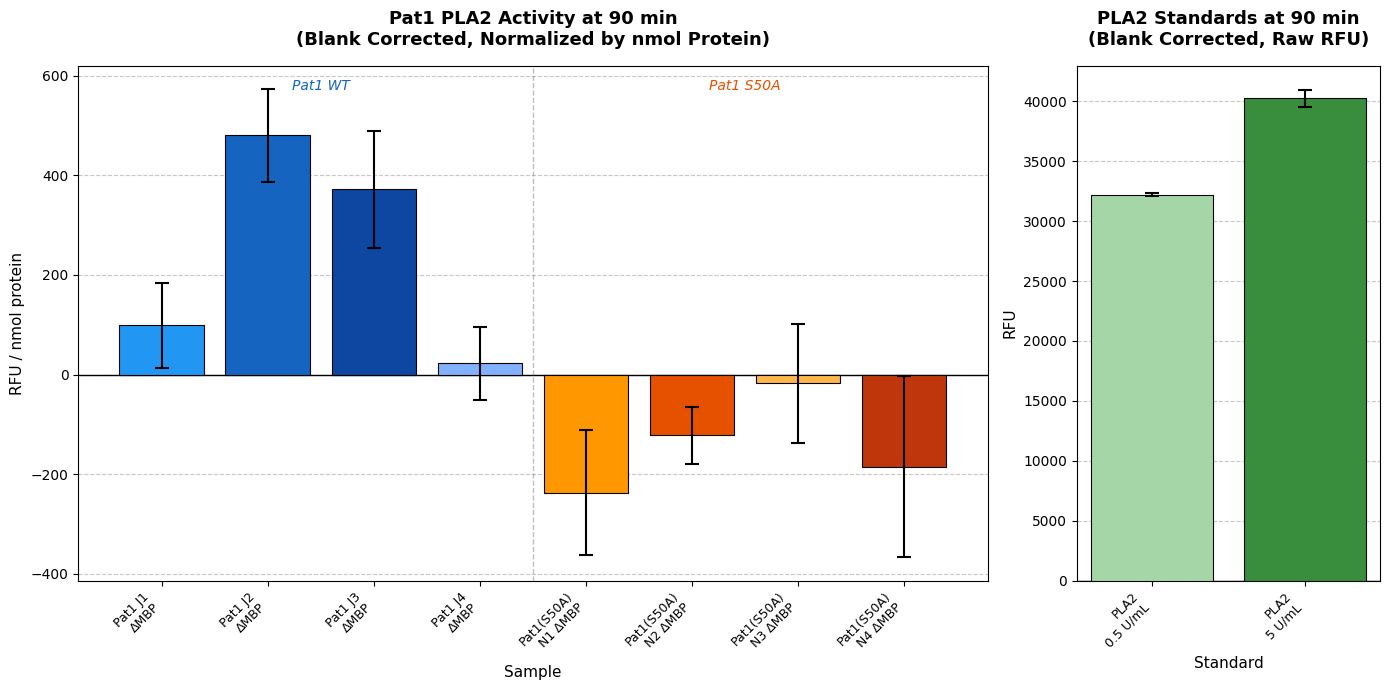


✓ Cell 4 complete


In [ ]:
# ============================================================
# CELL 4: Means, Standard Deviations, Normalization & Graphing
# ============================================================
# PURPOSE:
#   Part A — Calculate mean and SD for all time points
#   Part B — Extract the 90 min endpoint
#   Part C — Normalize by nmol protein loaded
#   Part D — Build the bar graph
# ============================================================


# --- SECTION 4A: Calculate Mean and SD Across Replicates ---
# We add mean and SD columns to a copy of blanked_df.
# This gives us a complete summary across all time points —
# useful now for the endpoint and later for kinetic curves.

summary_df = blanked_df.copy()

# Calculate mean across the three replicate columns
summary_df['mean_rfu'] = summary_df[['rep_1', 'rep_2', 'rep_3']].mean(axis=1)

# Calculate standard deviation across the three replicate columns
summary_df['sd_rfu'] = summary_df[['rep_1', 'rep_2', 'rep_3']].std(axis=1)
# .std() works exactly like .mean() — same axis=1 logic
# axis=1 = calculate across columns (across replicates) per row
# By default Pandas uses ddof=1 (sample SD, not population SD)
# This is correct for technical triplicates

print("✓ Mean and SD calculated")
print(f"\nSummary DataFrame preview:")
display(summary_df[['time_s', 'time_min', 'sample',
                     'mean_rfu', 'sd_rfu']].head(10))


# --- SECTION 4B: Extract the 90 Minute Endpoint ---
# Define the endpoint clearly at the top so it's easy
# to change for future experiments

ENDPOINT_MIN = 90       # your standard comparison time point
ENDPOINT_S = 5400       # 90 min in seconds after time offset
OUTPUT_FOLDER = '/content/drive/MyDrive/Samantha_WelchLab'
# *** UPDATE your_folder to match where you want figures saved ***

# Filter summary_df to just the endpoint time point
endpoint_df = summary_df[
    summary_df['time_s'] == ENDPOINT_S
].copy()

# Quick verification
print(f"\n✓ Endpoint extracted: {ENDPOINT_MIN} min ({ENDPOINT_S}s)")
print(f"  Rows extracted: {len(endpoint_df)} (expected 11 — one per sample)")
print(f"\nEndpoint data:")
display(endpoint_df[['sample', 'mean_rfu', 'sd_rfu']])


# --- SECTION 4C: Normalize by nmol Protein Loaded ---
# We normalize Pat1 samples by nmol loaded so that differences
# in protein concentration between wells don't drive the result.
# The PLA2 standards are handled separately — they use U/mL.

# Add empty normalization columns to endpoint_df
endpoint_df['nmol_loaded'] = None
endpoint_df['mean_rfu_per_nmol'] = None
endpoint_df['sd_rfu_per_nmol'] = None

# Loop through each row and apply normalization where applicable
for idx, row in endpoint_df.iterrows():
    # iterrows() gives us both the index AND the full row
    # as a Series — similar to .items() for dictionaries
    # idx = the row's index label
    # row = all the values in that row

    sample = row['sample']

    if sample in protein_data:
        # This sample has protein amount data — normalize it
        nmol = protein_data[sample]['nmol_loaded']

        endpoint_df.at[idx, 'nmol_loaded'] = nmol
        endpoint_df.at[idx, 'mean_rfu_per_nmol'] = row['mean_rfu'] / nmol
        endpoint_df.at[idx, 'sd_rfu_per_nmol']   = row['sd_rfu']  / nmol
        # .at[idx, column] is the precise way to set a single
        # cell value in a DataFrame by row index and column name
        # It's safer than other methods when modifying in a loop

    elif sample in pla2_standards:
        # PLA2 standards — no protein normalization
        # We leave mean_rfu_per_nmol as None for these
        endpoint_df.at[idx, 'nmol_loaded'] = None

print("\n✓ Normalization applied")
print("\nNormalized endpoint data:")
display(endpoint_df[['sample', 'mean_rfu', 'sd_rfu',
                      'nmol_loaded', 'mean_rfu_per_nmol',
                      'sd_rfu_per_nmol']])


# --- SECTION 4D: Build the Bar Graph ---
# We split the graph into two parts:
#   Left side:  Pat1 samples (normalized by nmol)
#   Right side: PLA2 standards (raw RFU, not normalized)
# This reflects that they are measured on different scales
# and cannot be directly compared numerically

# ── Prepare the two data subsets ──

# Pat1 samples only — sorted by sample name for consistent ordering
pat1_plot_df = endpoint_df[
    endpoint_df['sample'].isin(protein_data.keys())
].sort_values('sample').reset_index(drop=True)
#isin makes a list of the matching sample names (as keys in protein_data)
#as compared to finding just one sample name
#reset the indeces to match the new alphabetical order of sample names

# PLA2 standards only
std_plot_df = endpoint_df[
    endpoint_df['sample'].isin(pla2_standards.keys())
].sort_values('sample').reset_index(drop=True)

# ── Define colors ──
# We use two color families to visually separate WT from S50A
# and keep standards visually distinct

# Assign colors per sample
color_map = {
    # Pat1 WT (J series) — shades of blue
    'Pat1_J1_delMBP':  '#2196F3',   # bright blue
    'Pat1_J2_delMBP':  '#1565C0',   # medium blue
    'Pat1_J3_delMBP':  '#0D47A1',   # dark blue
    'Pat1_J4_delMBP':  '#82B1FF',   # light blue

    # Pat1 S50A (N series) — shades of orange
    'Pat1_S50A_N1_delMBP':  '#FF9800',   # bright orange
    'Pat1_S50A_N2_delMBP':  '#E65100',   # dark orange
    'Pat1_S50A_N3_delMBP':  '#FFB74D',   # light orange
    'Pat1_S50A_N4_delMBP':  '#BF360C',   # deep orange

    # Standards — shades of green
    'PLA2_ST_5':    '#388E3C',   # dark green
    'PLA2_ST_0pt5': '#A5D6A7',   # light green
}

# ── Build the figure ──
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 7),
    gridspec_kw={'width_ratios': [3, 1]}
)

# ── Define clean display labels ──
# \n creates a line break so labels are more readable
# We use proper scientific notation in the labels
label_map = {
    'Pat1_J1_delMBP':      'Pat1 J1\nΔMBP',
    'Pat1_J2_delMBP':      'Pat1 J2\nΔMBP',
    'Pat1_J3_delMBP':      'Pat1 J3\nΔMBP',
    'Pat1_J4_delMBP':      'Pat1 J4\nΔMBP',
    'Pat1_S50A_N1_delMBP': 'Pat1(S50A)\nN1 ΔMBP',
    'Pat1_S50A_N2_delMBP': 'Pat1(S50A)\nN2 ΔMBP',
    'Pat1_S50A_N3_delMBP': 'Pat1(S50A)\nN3 ΔMBP',
    'Pat1_S50A_N4_delMBP': 'Pat1(S50A)\nN4 ΔMBP',
}

std_label_map = {
    'PLA2_ST_5':    'PLA2\n5 U/mL',
    'PLA2_ST_0pt5': 'PLA2\n0.5 U/mL',
}

# ── Left Panel: Pat1 Samples ──
bars1 = ax1.bar(
    x=range(len(pat1_plot_df)),
    # We use range() instead of sample names directly
    # so we have full control over positioning
    height=pat1_plot_df['mean_rfu_per_nmol'],
    yerr=pat1_plot_df['sd_rfu_per_nmol'],
    color=[color_map[s] for s in pat1_plot_df['sample']],
    capsize=5,
    edgecolor='black',
    linewidth=0.8,
    error_kw={
        'elinewidth': 1.5,
        'ecolor': 'black',
        'capthick': 1.5
    },
    zorder=3   # draws bars on top of grid lines
)

# Add horizontal line at y=0
# Makes active vs inactive distinction immediately clear
ax1.axhline(
    y=0,
    color='black',
    linewidth=1.0,
    linestyle='-',
    zorder=2    # draws line above grid but below bars
)

# Add subtle vertical separator between WT and S50A series
# J4 is at position 3, S50A_N1 is at position 4
# We draw the line at x=3.5 (between them)
ax1.axvline(
    x=3.5,
    color='gray',
    linewidth=1.0,
    linestyle='--',
    alpha=0.5,
    zorder=2
)

# Add series labels above the bars
# These label the two groups visually
ax1.text(
    1.5, ax1.get_ylim()[1] * 0.92,   # x=center of J series, y=near top
    'Pat1 WT',
    ha='center',
    fontsize=10,
    fontstyle='italic',
    color='#1565C0'
)
ax1.text(
    5.5, ax1.get_ylim()[1] * 0.92,   # x=center of S50A series
    'Pat1 S50A',
    ha='center',
    fontsize=10,
    fontstyle='italic',
    color='#E65100'
)

ax1.set_title(
    f'Pat1 PLA2 Activity at {ENDPOINT_MIN} min\n'
    f'(Blank Corrected, Normalized by nmol Protein)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax1.set_xlabel('Sample', fontsize=11)
ax1.set_ylabel('RFU / nmol protein', fontsize=11)

# Clean x tick labels using label_map
ax1.set_xticks(range(len(pat1_plot_df)))
ax1.set_xticklabels(
    [label_map[s] for s in pat1_plot_df['sample']],
    rotation=45,
    ha='right',
    fontsize=9
)

ax1.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
ax1.set_axisbelow(True)

# ── Right Panel: PLA2 Standards ──
bars2 = ax2.bar(
    x=range(len(std_plot_df)),
    height=std_plot_df['mean_rfu'],
    yerr=std_plot_df['sd_rfu'],
    color=[color_map[s] for s in std_plot_df['sample']],
    capsize=5,
    edgecolor='black',
    linewidth=0.8,
    error_kw={
        'elinewidth': 1.5,
        'ecolor': 'black',
        'capthick': 1.5
    },
    zorder=3
)

ax2.axhline(y=0, color='black', linewidth=1.0, linestyle='-', zorder=2)

ax2.set_title(
    f'PLA2 Standards at {ENDPOINT_MIN} min\n(Blank Corrected, Raw RFU)',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax2.set_xlabel('Standard', fontsize=11)
ax2.set_ylabel('RFU', fontsize=11)

ax2.set_xticks(range(len(std_plot_df)))
ax2.set_xticklabels(
    [std_label_map[s] for s in std_plot_df['sample']],
    rotation=45,
    ha='right',
    fontsize=9
)

ax2.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
ax2.set_axisbelow(True)

# ── Final Formatting ──
plt.tight_layout()

plt.savefig(
    f'{OUTPUT_FOLDER}/PLA2_activity_{ENDPOINT_MIN}min.png',
    dpi=300,
    bbox_inches='tight'
)
print(f"\n✓ Figure saved as 'PLA2_activity_{ENDPOINT_MIN}min.png'")
plt.show()
print("\n✓ Cell 4 complete")

In [ ]:
# ============================================================
# SECTION 2: REUSABLE GRAPHING FUNCTION + HISTORICAL DATA
# ============================================================
# Cells below this point contain:
# - A reusable plot_pla2_activity() function (Cell 5)
# - Individual experiment datasets (Cell 6+)
# - Each dataset calls the function to generate figures
# ============================================================

In [ ]:
# ============================================================
# CELL 5: Reusable PLA2 Activity Graphing Function
# ============================================================
# PURPOSE: Define a function that accepts any experiment
# dataset in our standard format and produces a
# publication-ready figure automatically.
# Define this ONCE — call it from any cell below.
# ============================================================


def plot_pla2_activity(
    experiment_data,
    output_folder,
    show_plot=True,
    group_labels=None,
    show_separator=False,
    legend_labels=None
):
    """
    Generates a publication-ready PLA2 activity bar graph.

    Parameters:
    -----------
    experiment_data : dict
        Standardized experiment dictionary
    output_folder : str
        Path to Google Drive folder for saving
    show_plot : bool
        Whether to display plot inline (default True)
    group_labels : list of (str, str) or None
        Optional. Two group label strings and their x positions.
        Format: [(label1, x_position1), (label2, x_position2)]
        e.g. [('-DDM', 1.5), ('+DDM', 5.5)]
        Pass None for no group labels (default)
    show_separator : bool
        Whether to draw vertical dashed line splitting bar groups
        Default False
    legend_labels : list of (str, str) or None
        Optional. Labels for solid and hatched bars in legend.
        Format: [(solid_label, hatch_label)]
        e.g. [('- DDM', '+ DDM')]
        Pass None for no legend (default)
    """

    # --- Unpack metadata ---
    name         = experiment_data['name']
    endpoint_min = experiment_data['endpoint_min']

    # --- Unpack sample data ---
    sample_labels  = [s[0] for s in experiment_data['samples']]
    sample_means   = [s[1] for s in experiment_data['samples']]
    sample_sds     = [s[2] for s in experiment_data['samples']]
    sample_colors  = experiment_data['colors']
    sample_hatches = experiment_data['hatches']

    # --- Unpack standard data ---
    std_labels  = [s[0] for s in experiment_data['standards']]
    std_means   = [s[1] for s in experiment_data['standards']]
    std_sds     = [s[2] for s in experiment_data['standards']]
    std_colors  = experiment_data['std_colors']
    std_hatches = experiment_data['std_hatches']

    # --- Build figure ---
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14, 7),
        gridspec_kw={'width_ratios': [3, 1]}
    )

    # --- Left panel: Experimental samples ---
    for i, (label, mean, sd, color, hatch) in enumerate(
        zip(sample_labels, sample_means, sample_sds,
            sample_colors, sample_hatches)):

        ax1.bar(
            x=i,
            height=mean,
            yerr=sd,
            color=color,
            hatch=hatch,
            capsize=5,
            edgecolor='black',
            linewidth=0.8,
            error_kw={
                'elinewidth': 1.5,
                'ecolor': 'black',
                'capthick': 1.5
            },
            zorder=3
        )

    # Reference line at y=0
    ax1.axhline(
        y=0, color='black',
        linewidth=1.0,
        linestyle='-',
        zorder=2
    )

    # --- Optional: vertical separator ---
    # Only drawn if show_separator=True
    if show_separator:
        n_per_group = len(sample_labels) // 2
        ax1.axvline(
            x=n_per_group - 0.5,
            color='gray',
            linewidth=1.0,
            linestyle='--',
            alpha=0.5,
            zorder=2
        )

    # --- Optional: group labels ---
    # Only added if group_labels is not None
    if group_labels is not None:
        # Calculate y position for labels
        # Uses the top of the current y axis range
        y_top = ax1.get_ylim()[1] * 0.95

        for label_text, x_pos in group_labels:
            ax1.text(
                x_pos,
                y_top,
                label_text,
                ha='center',
                fontsize=10,
                fontstyle='italic',
                color='#1565C0'
            )

    # --- Optional: hatch legend ---
    # Only added if legend_labels is not None
    if legend_labels is not None:
        from matplotlib.patches import Patch
        solid_label, hatch_label = legend_labels
        legend_elements = [
            Patch(facecolor='white', edgecolor='black',
                  label=solid_label),
            Patch(facecolor='white', edgecolor='black',
                  hatch='///', label=hatch_label),
        ]
        ax1.legend(
            handles=legend_elements,
            loc='upper right',
            fontsize=9,
            framealpha=0.8
        )

    # --- Axis formatting ---
    ax1.set_title(
        f'{name}\n'
        f'PLA2 Activity at {endpoint_min} min\n'
        f'(Blank Corrected, Normalized by nmol Protein)',
        fontsize=13,
        fontweight='bold',
        pad=15
    )
    ax1.set_xlabel('Sample', fontsize=11)
    ax1.set_ylabel('RFU / nmol protein', fontsize=11)
    ax1.set_xticks(range(len(sample_labels)))
    ax1.set_xticklabels(
        sample_labels,
        rotation=45,
        ha='right',
        fontsize=9
    )
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax1.set_axisbelow(True)

    # --- Right panel: Standards ---
    for i, (label, mean, sd, color, hatch) in enumerate(
        zip(std_labels, std_means, std_sds,
            std_colors, std_hatches)):

        ax2.bar(
            x=i,
            height=mean,
            yerr=sd,
            color=color,
            hatch=hatch,
            capsize=5,
            edgecolor='black',
            linewidth=0.8,
            error_kw={
                'elinewidth': 1.5,
                'ecolor': 'black',
                'capthick': 1.5
            },
            zorder=3
        )

    ax2.axhline(
        y=0, color='black',
        linewidth=1.0,
        linestyle='-',
        zorder=2
    )
    ax2.set_title(
        f'PLA2 Standards at {endpoint_min} min\n'
        f'(Blank Corrected, Raw RFU)',
        fontsize=13,
        fontweight='bold',
        pad=15
    )
    ax2.set_xlabel('Standard', fontsize=11)
    ax2.set_ylabel('RFU', fontsize=11)
    ax2.set_xticks(range(len(std_labels)))
    ax2.set_xticklabels(
        std_labels,
        rotation=45,
        ha='right',
        fontsize=9
    )
    ax2.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax2.set_axisbelow(True)

    # --- Save and show ---
    plt.tight_layout()

    import os
    os.makedirs(output_folder, exist_ok=True)

    save_path = f'{output_folder}/{name}_activity_{endpoint_min}min.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure saved: {save_path}")

    if show_plot:
        plt.show()

    return fig

print("✓ plot_pla2_activity() function defined")
print("  Optional features: group_labels, show_separator, legend_labels")

✓ plot_pla2_activity() function defined
  Optional features: group_labels, show_separator, legend_labels


✓ Figure saved: /content/drive/MyDrive/Samantha_WelchLab/MBP_Pat1_DDM_2026_06_18_activity_90min.png


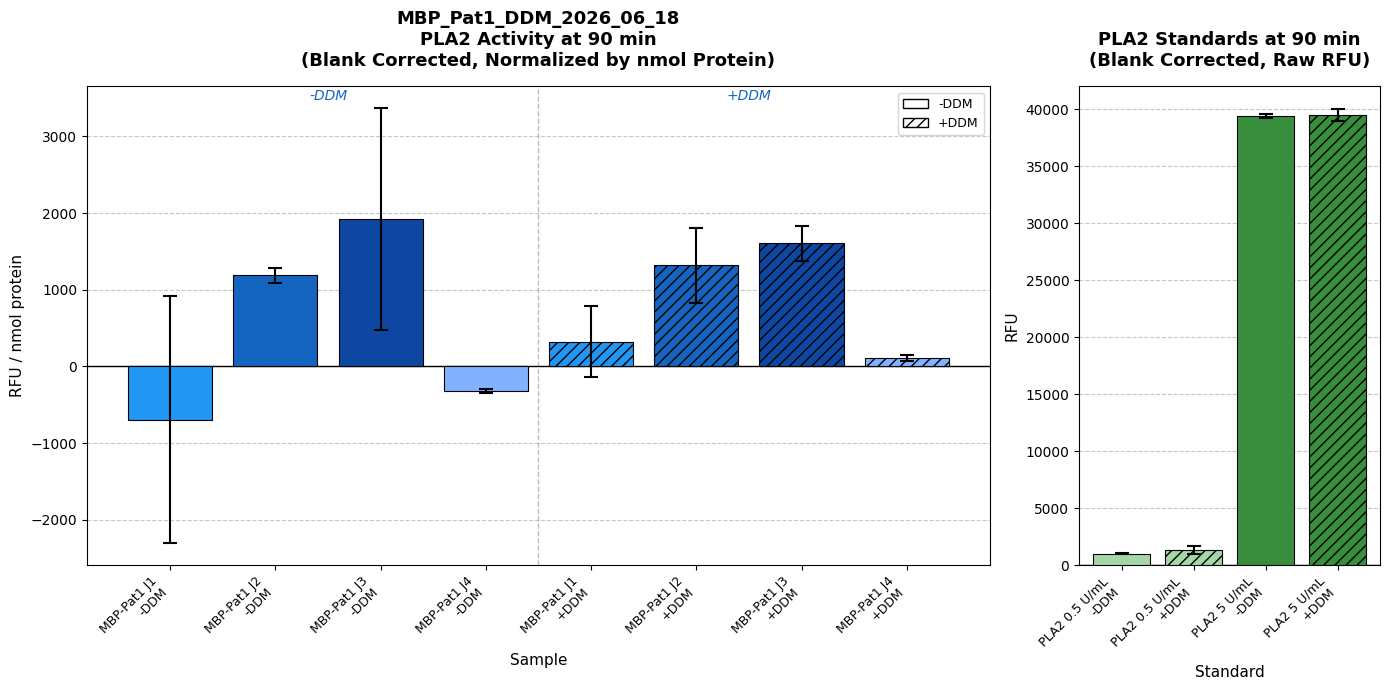

In [ ]:
# ============================================================
# CELL 6: MBP-Pat1 DDM Experiment — 2026-06-18
# ============================================================
# PURPOSE: Define the dataset and call the graphing function
# ============================================================

MBP_Pat1_DDM_2026_06_18 = {

    'name':         'MBP_Pat1_DDM_2026_06_18',
    'endpoint_min': 90,
    'mw_kda':       98.2,

    # (label, mean_rfu_per_nmol, sd_rfu_per_nmol)
    'samples': [
        ('MBP-Pat1 J1\n-DDM',  -694,  1613),
        ('MBP-Pat1 J2\n-DDM',  1188,    98),
        ('MBP-Pat1 J3\n-DDM',  1922,  1446),
        ('MBP-Pat1 J4\n-DDM',  -318,    23),
        ('MBP-Pat1 J1\n+DDM',   323,   466),
        ('MBP-Pat1 J2\n+DDM',  1317,   484),
        ('MBP-Pat1 J3\n+DDM',  1609,   228),
        ('MBP-Pat1 J4\n+DDM',   108,    40),
    ],

    # Blues by fraction, repeated for -DDM and +DDM
    'colors': [
        '#2196F3',   # J1
        '#1565C0',   # J2
        '#0D47A1',   # J3
        '#82B1FF',   # J4
        '#2196F3',   # J1 +DDM
        '#1565C0',   # J2 +DDM
        '#0D47A1',   # J3 +DDM
        '#82B1FF',   # J4 +DDM
    ],

    # Solid for -DDM, hatched for +DDM
    'hatches': ['', '', '', '', '///', '///', '///', '///'],

    # (label, mean_rfu, sd_rfu)
    'standards': [
        ('PLA2 0.5 U/mL\n-DDM',   1014,   63),
        ('PLA2 0.5 U/mL\n+DDM',   1312,  339),
        ('PLA2 5 U/mL\n-DDM',    39397,  176),
        ('PLA2 5 U/mL\n+DDM',    39486,  527),
    ],

    'std_colors':  ['#A5D6A7', '#A5D6A7', '#388E3C', '#388E3C'],
    'std_hatches': ['', '///', '', '///'],
}

# DDM-specific features passed explicitly here
# not hardcoded in the function
#CALLING THE FUNCTION
fig = plot_pla2_activity(
    experiment_data = MBP_Pat1_DDM_2026_06_18,
    output_folder   = OUTPUT_FOLDER,
    show_separator  = True,
    group_labels    = [('-DDM', 1.5), ('+DDM', 5.5)],
    legend_labels   = ('-DDM', '+DDM')
)

✓ Figure saved: /content/drive/MyDrive/Samantha_WelchLab/MBP_Pat1_newbatchtest_2026_05_19_activity_90min.png


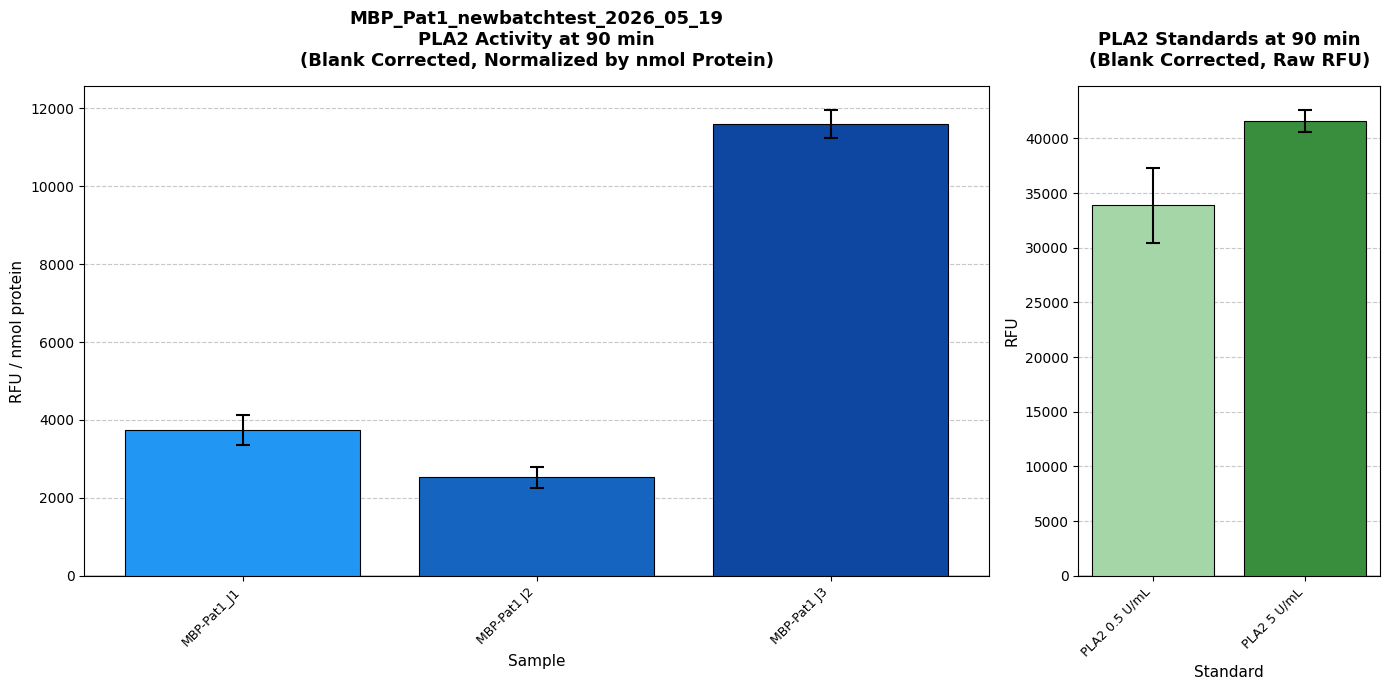

In [ ]:
# ============================================================
# CELL 7: MBP-Pat1 Testing New Batch — 2026-05-19
# ============================================================
# PURPOSE: Define the dataset and call the graphing function
# ============================================================

new_experiment = {
    'name':         'MBP_Pat1_newbatchtest_2026_05_19',
    'endpoint_min': 90,
    'mw_kda':       98.2,
    'samples':      [
        ('MBP-Pat1_J1', 3748,  383),
        ('MBP-Pat1 J2',  2525,  280),
        ('MBP-Pat1 J3',  11609,  357),
    ],
      # (label, mean_rfu_per_nmol, sd_rfu_per_nmol)
    'colors':       [
        '#2196F3',   # J1
        '#1565C0',   # J2
        '#0D47A1',   # J3

                     ],

    'hatches':      ['','',''],
    'standards':    [
        ('PLA2 0.5 U/mL',   33865,   3404),
        ('PLA2 5 U/mL',    41609,  1012),
                     ],
     # (label, mean_rfu, sd_rfu)
    'std_colors':   ['#A5D6A7', '#388E3C'],
    'std_hatches':  ['',''],
}

fig = plot_pla2_activity(new_experiment, OUTPUT_FOLDER)

✓ Figure saved: /content/drive/MyDrive/Samantha_WelchLab/Pat1_frozentest_2026_07_21_activity_90min.png


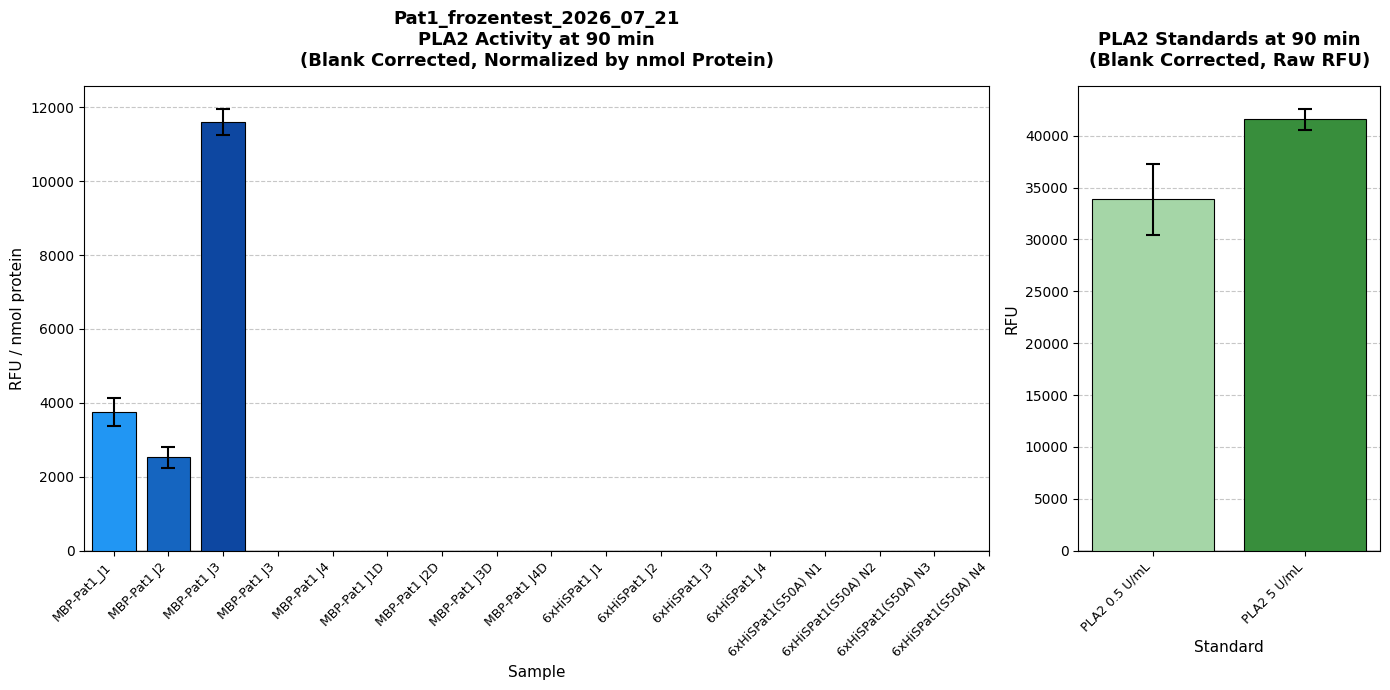

In [ ]:
# ============================================================
# CELL 8: Testing frozen stock activity vs fresh activity — 2026-07-21
# ============================================================
# PURPOSE: Define the dataset and call the graphing function
# ============================================================

new_experiment = {
    'name':         'Pat1_frozentest_2026_07_21',
    'endpoint_min': 90,
    'mw_kda':       98.2,
    'samples':      [
        ('MBP-Pat1_J1', 3748,  383),
        ('MBP-Pat1 J2',  2525,  280),
        ('MBP-Pat1 J3',  11609,  357),
        ('MBP-Pat1 J3',  11609,  357),
        ('MBP-Pat1 J4',  11609,  357),
        ('MBP-Pat1 J1D',  11609,  357),
        ('MBP-Pat1 J2D',  11609,  357),
        ('MBP-Pat1 J3D',  11609,  357),
        ('MBP-Pat1 J4D',  11609,  357),
        ('6xHiSPat1 J1',  11609,  357),
        ('6xHiSPat1 J2',  11609,  357),
        ('6xHiSPat1 J3',  11609,  357),
        ('6xHiSPat1 J4',  11609,  357),
        ('6xHiSPat1(S50A) N1',  11609,  357),
        ('6xHiSPat1(S50A) N2',  11609,  357),
        ('6xHiSPat1(S50A) N3',  11609,  357),
        ('6xHiSPat1(S50A) N4',  11609,  357),

    ],
      # (label, mean_rfu_per_nmol, sd_rfu_per_nmol)
    'colors':       [
        '#2196F3',   # J1
        '#1565C0',   # J2
        '#0D47A1',   # J3

                     ],

    'hatches':      ['','',''],
    'standards':    [
        ('PLA2 0.5 U/mL',   33865,   3404),
        ('PLA2 5 U/mL',    41609,  1012),
                     ],
     # (label, mean_rfu, sd_rfu)
    'std_colors':   ['#A5D6A7', '#388E3C'],
    'std_hatches':  ['',''],
}

fig = plot_pla2_activity(new_experiment, OUTPUT_FOLDER)